# Chapter 11. Deep Learning in Chemistry

## 11.3. Application of Deep Learning in Chemistry

MLP networks can be used to predict various chemical systems. In the following section, we will apply MLP to predict molecular properties and reaction outcomes.

### 11.3.1. Prediction of Molecular Properies

#### 11.3.1.1. Regression

In this section, we will build an MLP network to predict the solubility of molecules:

**a. Import modules**

In [1]:
# Import modules
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

**b. Load data**

In [2]:
# Load the dataset
data_file_path = '.\\datasets\\Solubility.csv'
df = pd.read_csv(data_file_path)
df.head()

,smiles,solubility
0,OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)...,-0.77
1,Cc1occc1C(=O)Nc2ccccc2,-3.30
2,CC(C)=CCCC(C)=CC(=O),-2.06
3,c1ccc2c(c1)ccc3c2ccc4c5ccccc5ccc43,-7.87
4,c1ccsc1,-1.33


In [3]:
# Get the list of SMILES
smiles_arr = df['smiles'].to_numpy()

# Get the output column
y = df['solubility'].to_numpy()

**c. Feature extraction**

In [4]:
# Define a function to extract a list of features from a molecule
def extract_features(mol):
    features = []
    features.append(Descriptors.MolWt(mol))          # molecular weight
    features.append(Descriptors.NumHeteroatoms(mol)) # number of heteroatoms
    features.append(Descriptors.RingCount(mol))      # number of rings
    features.append(Descriptors.NumHAcceptors(mol))  # number of hydrogen bond donor
    features.append(Descriptors.NumHDonors(mol))     # number of hydrogen bond accepter
    features.append(Descriptors.FractionCSP3(mol))   # fraction of SP3-hybridized carbons
    features.append(Descriptors.MolLogP(mol))        # logP
    features.append(Descriptors.TPSA(mol))           # topological polar surface area
    
    return features

In [5]:
# Create the list of features for molecules
x = []

# Loop through the SMILES list
pbar = tqdm(range(len(smiles_arr)))
for i in pbar:
    # Get the SMILES for each molecule
    smiles = smiles_arr[i]
    
    # Create a molecule object from the SMILES
    mol = Chem.MolFromSmiles(smiles)
    
    # Get descriptors
    features = extract_features(mol)
    x.append(features)
    
    # Print progress
    pbar.set_description('{}/{} molecules processed |'.format(i + 1, len(smiles_arr)))
    
# Convert list to numpy array
x = np.array(x)

1121/1121 molecules processed |: 100%|███████████████████████████████████████████| 1121/1121 [00:01<00:00, 1067.84it/s]


**d. Data processing**

In [6]:
# Set the random seed
random_seed = 0
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)

In [7]:
# Define input and output scalers
input_scaler = MinMaxScaler(feature_range=(0, 1))
output_scaler = MinMaxScaler(feature_range=(0, 1))

# Scale the data
x_scaled = input_scaler.fit_transform(x)
y_scaled = output_scaler.fit_transform(y.reshape(-1, 1)).reshape(-1)

In [8]:
# Split the data into training and testing sets
x_train_scaled, x_test_scaled, y_train_scaled, y_test_scaled = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=random_seed)

# Split the training dataset into training and validation sets
x_train_scaled, x_val_scaled, y_train_scaled, y_val_scaled = train_test_split(x_train_scaled, y_train_scaled, test_size=0.25, random_state=random_seed)

**e. Create model**

In [9]:
# Define the regression model class
class RegressionModel(nn.Module):
    def __init__(self, n_inputs, n_layers, n_hiddens, n_outputs):
        super(RegressionModel, self).__init__()
        self.hiddens = nn.ModuleList()
        self.hiddens.append(nn.Linear(n_inputs, n_hiddens))
        for _ in range(1, n_layers):
            self.hiddens.append(nn.Linear(n_hiddens, n_hiddens))
        self.output = nn.Linear(n_hiddens, n_outputs)

    def forward(self, x):
        for hidden in self.hiddens:
            x = torch.relu(hidden(x))
        return self.output(x)

In [10]:
# Instantiate the model
n_inputs = x_train_scaled.shape[1]
n_layers = 2
n_hiddens = 32
n_outputs = 1
model = RegressionModel(n_inputs, n_layers, n_hiddens, n_outputs)

In [11]:
# Choose the device to train the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Send the model and all tensors to device (except y_test_scaled because it is not needed)
model.float().to(device)
x_train_scaled = torch.tensor(x_train_scaled, device=device, dtype=torch.float)
y_train_scaled = torch.tensor(y_train_scaled, device=device, dtype=torch.float)
x_val_scaled = torch.tensor(x_val_scaled, device=device, dtype=torch.float)
y_val_scaled = torch.tensor(y_val_scaled, device=device, dtype=torch.float)
x_test_scaled = torch.tensor(x_test_scaled, device=device, dtype=torch.float)

**f. Training**

In [12]:
# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

In [13]:
# Define the train function
def train(x, y):
    # Set the model to train mode
    model.train()
    
    # Forward pass
    output = model(x)
    loss = criterion(output, y)
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [14]:
# Define the validation function
@torch.no_grad()
def validation(x, y):
     # Set the model to evaluation mode
    model.eval()
    
    # Forward pass
    output = model(x)
    loss = criterion(output, y)
        
    return loss.item()

In [15]:
# Create lists of losses for visualization
train_losses = []
val_losses = []

# Train the model
num_epochs = 1000
progress_bar = tqdm(range(num_epochs))
for epoch in progress_bar:
    train_loss = train(x_train_scaled, y_train_scaled.unsqueeze(1))
    val_loss = validation(x_val_scaled, y_val_scaled.unsqueeze(1))
    
    # Add loss to lists for visualization
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Print progress
    progress_bar.set_description(f'Epoch [{epoch+1}/{num_epochs}], Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}') 

Epoch [1000/1000], Train loss: 0.0021, Validation loss: 0.0021: 100%|█████████████| 1000/1000 [00:02<00:00, 392.93it/s]


Text(0, 0.5, 'MSE loss')

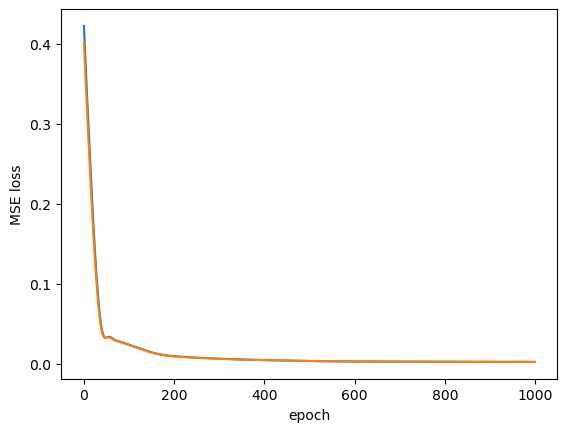

In [16]:
# Visualize MSE loss values over time
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('epoch')
plt.ylabel('MSE loss')

**g. Evaluation**

In [17]:
# Set the model to evaluation mode
model.eval()

# Forward the test set
y_pred_scaled = model(x_test_scaled)

# Scale output back to original range
y_pred = output_scaler.inverse_transform(y_pred_scaled.detach().cpu().numpy().reshape(-1, 1)).reshape(-1)

# Transform the test set back to original scale
y_test = output_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).reshape(-1)

In [18]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 0.5265
Mean Squared Error (MSE): 0.5061
Root Mean Squared Error (RMSE): 0.7114
R^2 Score: 0.8979


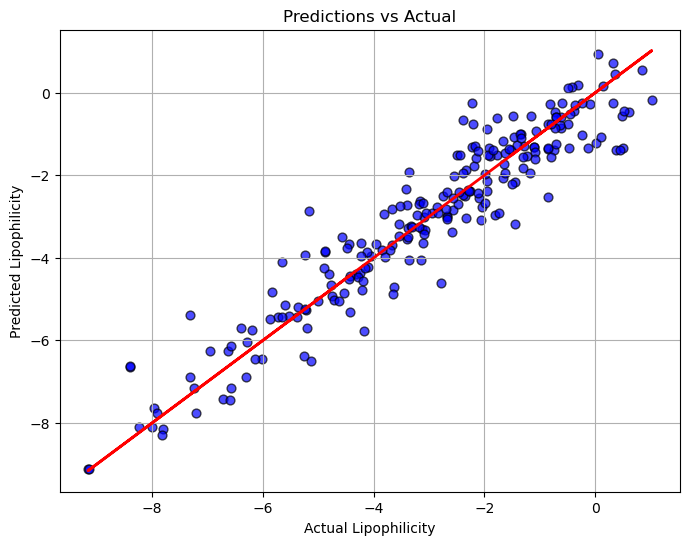

In [19]:
# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.7, s=40)
plt.plot(y_test, y_test, color='red', linewidth=2)  # Ideal line for perfect predictions
plt.xlabel('Actual Lipophilicity')
plt.ylabel('Predicted Lipophilicity')
plt.title('Predictions vs Actual')
plt.grid(True)
plt.show()

**h. Save and load model**

In [20]:
# Save model
model_name = 'mlp_model'
file_name = f'{model_name}_{num_epochs}.ckpt'
torch.save(model.state_dict(), file_name)

In [21]:
# Load model
file_name = f'mlp_model_1000.ckpt'
loaded_model = RegressionModel(n_inputs, n_layers, n_hiddens, n_outputs)
loaded_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>

#### 11.3.1.2. Classification

In this section, we will build an MLP network to predict whether a molecule can penetrate the blood-brain barrier.

**a. Import modules**

In [22]:
# Import modules
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from rdkit import Chem
from rdkit.Avalon import pyAvalonTools
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

**b. Load data**

In [23]:
# Load the dataset
data_file_path = '.\\datasets\\BBBP.csv'
df = pd.read_csv(data_file_path)
df.head()

,num,name,p_np,smiles
0,1,Propanolol,1,[Cl].CC(C)NCC(O)COc1cccc2ccccc12
1,2,Terbutylchlorambucil,1,C(=O)(OC(C)(C)C)CCCc1ccc(cc1)N(CCCl)CCCl
2,3,40730,1,c12c3c(N4CCN(C)CC4)c(F)cc1c(c(C(O)=O)cn2C(C)CO...
3,4,24,1,C1CCN(CC1)Cc1cccc(c1)OCCCNC(=O)C
4,5,cloxacillin,1,Cc1onc(c2ccccc2Cl)c1C(=O)N[C@H]3[C@H]4SC(C)(C)...


In [24]:
# Get the list of SMILES
smiles_arr = df['smiles'].to_numpy()

# Get the output column
output_arr = df['p_np'].to_numpy()

**c. Feature extraction**

In [25]:
# Define a function to extract a list of features from a molecule
def extract_features(mol):
    avalon_fp = pyAvalonTools.GetAvalonFP(mol, nBits=512) # Avalon fingerprint
    features = np.array(avalon_fp)
        
    return features

In [26]:
# Create the list of features for molecules
x = []
y = []

# Loop through the SMILES list
pbar = tqdm(range(len(smiles_arr)))
for i in pbar:
    # Get the SMILES for each molecule
    smiles = smiles_arr[i]
    
    # Create a molecule object from the SMILES
    mol = Chem.MolFromSmiles(smiles)
    
    # Get descriptors (skip if can't extract)
    try:
        features = extract_features(mol)
        x.append(features)
        y.append(output_arr[i])
    except:
        continue
    
    # Print progress
    pbar.set_description('{}/{} molecules processed |'.format(i + 1, len(smiles_arr)))
    
# Convert list to numpy array
x = np.array(x)
y = np.array(y)

59/2050 molecules processed |:   3%|█▎                                              | 56/2050 [00:00<00:03, 559.79it/s][10:38:45] Explicit valence for atom # 1 N, 4, is greater than permitted
[10:38:45] WARNING: not removing hydrogen atom without neighbors
61/2050 molecules processed |:   3%|█▎                                              | 56/2050 [00:00<00:03, 559.79it/s][10:38:45] Explicit valence for atom # 6 N, 4, is greater than permitted
127/2050 molecules processed |:   6%|██▋                                           | 120/2050 [00:00<00:03, 606.90it/s][10:38:45] WARNING: not removing hydrogen atom without neighbors
196/2050 molecules processed |:   9%|████▏                                         | 184/2050 [00:00<00:03, 621.95it/s][10:38:45] WARNING: not removing hydrogen atom without neighbors
223/2050 molecules processed |:   9%|████▏                                         | 184/2050 [00:00<00:03, 621.95it/s][10:38:45] WARNING: not removing hydrogen atom without neighbors

1915/2050 molecules processed |:  91%|███████████████████████████████████████▉    | 1859/2050 [00:03<00:00, 637.84it/s][10:38:48] WARNING: not removing hydrogen atom without neighbors
1988/2050 molecules processed |:  97%|██████████████████████████████████████████▋ | 1988/2050 [00:03<00:00, 628.67it/s][10:38:48] WARNING: not removing hydrogen atom without neighbors
2050/2050 molecules processed |: 100%|████████████████████████████████████████████| 2050/2050 [00:03<00:00, 603.93it/s]


**d. Data processing**

In [27]:
# Set the random seed
random_seed = 0
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)

In [28]:
# Apply a variance threshold to remove input columns with only one value.
var_thresholder = VarianceThreshold(threshold=0.01)
x_var_thresh = var_thresholder.fit_transform(x)

# Apply PCA to reduce the dimensionality
pca = PCA(n_components=32)
x_pca = pca.fit_transform(x_var_thresh)

In [29]:
# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x_pca, y, test_size=0.2, random_state=random_seed)

# Split the training dataset into training and validation sets
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.25, random_state=random_seed)

**e. Create model**

In [30]:
# Define the classification model class
class ClassificationModel(nn.Module):
    def __init__(self, n_inputs, n_layers, n_hiddens, n_outputs):
        super(ClassificationModel, self).__init__()
        self.hiddens = nn.ModuleList()
        self.hiddens.append(nn.Linear(n_inputs, n_hiddens))
        for _ in range(1, n_layers):
            self.hiddens.append(nn.Linear(n_hiddens, n_hiddens))
        self.output = nn.Linear(n_hiddens, n_outputs)

    def forward(self, x):
        for hidden in self.hiddens:
            x = torch.sigmoid(hidden(x))
        return self.output(x)

In [31]:
# Instantiate the model
n_inputs = x_train.shape[1]
n_layers = 3
n_hiddens = 64
n_outputs = 1
model = ClassificationModel(n_inputs, n_layers, n_hiddens, n_outputs)

In [32]:
# Choose the device to train the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Send the model and all tensors to device (except y_test because it is not needed)
model.float().to(device)

x_train = torch.tensor(x_train, device=device, dtype=torch.float)
y_train = torch.tensor(y_train, device=device, dtype=torch.float)
x_val = torch.tensor(x_val, device=device, dtype=torch.float)
y_val = torch.tensor(y_val, device=device, dtype=torch.float)
x_test = torch.tensor(x_test, device=device, dtype=torch.float)

**f. Training**

In [33]:
# Define the loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=0.05)

In [34]:
# Define the train function
def train(x, y):
    # Set the model to train mode
    model.train()
    
    # Forward pass
    output = model(x)
    loss = criterion(output, y)
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [35]:
# Define the validation function
def validation(x, y):
    # Set the model to evaluation mode
    model.eval()
    
    # Forward pass
    outputs = model(x)
    loss = criterion(outputs, y)
    
    return loss.item()

In [36]:
# Create lists of losses for visualization
train_losses = []
val_losses = []

# Train the model
num_epochs = 100
progress_bar = tqdm(range(num_epochs))
for epoch in progress_bar:
    train_loss = train(x_train, y_train.unsqueeze(1))
    val_loss = validation(x_val, y_val.unsqueeze(1))
    
    # Add loss to lists for visualization
    train_losses.append(train_loss)
    val_losses.append(val_loss)
        
    # Print progress
    progress_bar.set_description(f'Epoch [{epoch+1}/{num_epochs}], Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}') 

Epoch [100/100], Train loss: 0.0770, Validation loss: 0.4290: 100%|█████████████████| 100/100 [00:00<00:00, 222.19it/s]


Text(0, 0.5, 'BCE loss with logits')

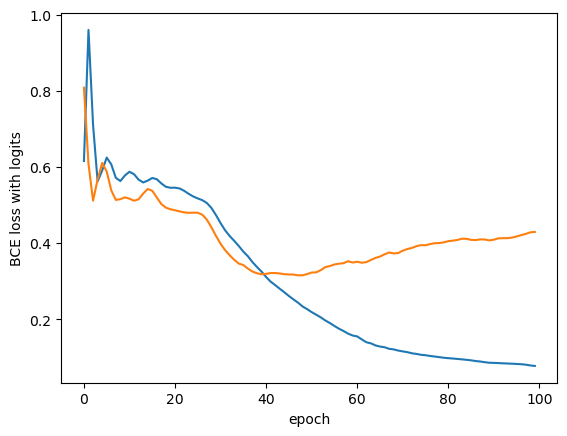

In [37]:
# Visualize MSE loss values over time
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('epoch')
plt.ylabel('BCE loss with logits')

**g. Evaluation**

In [38]:
# Set the model to evaluation mode
model.eval()

# Forward the test set
logits = model(x_test)
probabilities = torch.sigmoid(logits)
y_pred = torch.round(probabilities).detach().cpu().numpy().reshape(-1)

Accuracy: 0.8750
Precision: 0.9185
Recall: 0.9214
F1 Score: 0.9199


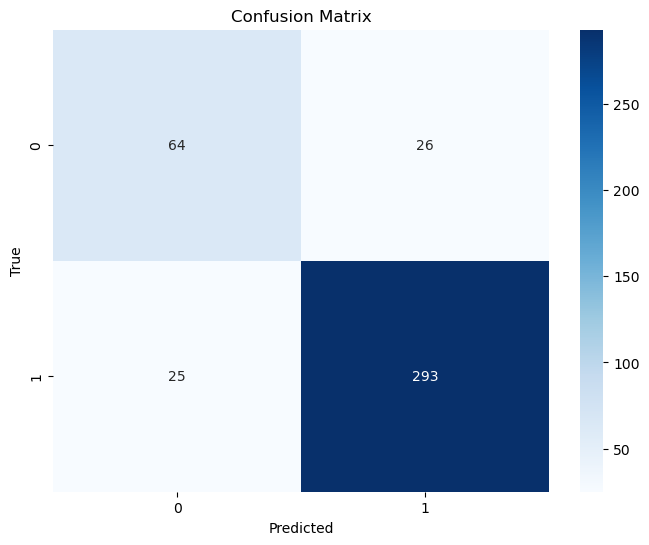

In [39]:
# Evaluate the model
cm = confusion_matrix(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**h. Make prediction**

In [40]:
# Define a new molecule
mol = Chem.MolFromSmiles('CCO') # ethanol

# Extract features
features = extract_features(mol)
features = np.array(features)

# Apply variance threshold
features_var_thresh = var_thresholder.transform(features.reshape(1, -1))

# Apply PCA
features_pca = pca.transform(features_var_thresh)

# Convert to tensor
x_pred = torch.tensor(features_pca, device=device, dtype=torch.float)

# Run model forward
logits = model(x_pred)
probabilities = torch.sigmoid(logits)
y_pred = torch.round(probabilities).int().detach().cpu().numpy().reshape(-1)[0]

# Show the prediction
print(y_pred)

1


**i. Save and load model**

In [41]:
# Save model
model_name = 'mlp_model'
file_name = f'{model_name}_{num_epochs}.ckpt'
torch.save(model.state_dict(), file_name)

In [42]:
# Load model
file_name = f'mlp_model_100.ckpt'
loaded_model = ClassificationModel(n_inputs, n_layers, n_hiddens, n_outputs)
loaded_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>

### 11.3.2. Prediction of Reaction Outcomes

In this section, we will build an MLP network to predict the yield of C-N coupling reactions (Buchwald-Hartwig reaction):

**a. Import modules**

In [43]:
# Import modules
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
import matplotlib.pyplot as plt
from tqdm import tqdm

**b. Load data**

In [44]:
# Load the dataset
data_file_path = '.\\datasets\\BuchwaldHartwigReactionYield.csv'
df = pd.read_csv(data_file_path)
df.head()

,Ligand,Additive,Base,Aryl halide,Yield
0,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P([C@@]3(C[...,CC1=CC(C)=NO1,CN(C)P(N(C)C)(N(C)C)=NP(N(C)C)(N(C)C)=NCC,ClC1=NC=CC=C1,70.410458
1,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P([C@@]3(C[...,O=C(OC)C1=CC=NO1,CN(C)P(N(C)C)(N(C)C)=NP(N(C)C)(N(C)C)=NCC,BrC1=NC=CC=C1,11.064457
2,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P(C3CCCCC3)...,O=C(OC)C1=CC=NO1,CN(C)P(N(C)C)(N(C)C)=NP(N(C)C)(N(C)C)=NCC,IC1=CC=C(CC)C=C1,10.223550
3,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P(C(C)(C)C)...,CCOC(C1=CON=C1)=O,CN1CCCN2C1=NCCC2,ClC1=CC=C(C(F)(F)F)C=C1,20.083383
4,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P([C@@]3(C[...,CC1=CC(C)=NO1,CN1CCCN2C1=NCCC2,ClC1=CC=C(OC)C=C1,0.492663


In [45]:
# Get the list of SMILES
ligand_smiles_arr = df['Ligand'].to_numpy()
additive_smiles_arr = df['Additive'].to_numpy()
base_smiles_arr = df['Base'].to_numpy()
aryl_halide_smiles_arr = df['Aryl halide'].to_numpy()

# Get the output
y = df['Yield'].to_numpy()

**c. Feature extraction**

In [46]:
# Define a function to extract a list of features from a molecule
def extract_features(mol):
    ap_fp = rdMolDescriptors.GetHashedAtomPairFingerprintAsBitVect(mol, nBits=512) # Atom-pairs fingerprint
    
    return ap_fp

In [47]:
# Create the list of features for molecules
x = []

# Loop through the SMILES list
pbar = tqdm(range(len(df)))
for i in pbar:
    # Create molecule objects from their SMILES
    ligand = Chem.MolFromSmiles(ligand_smiles_arr[i])
    additive = Chem.MolFromSmiles(additive_smiles_arr[i])
    base = Chem.MolFromSmiles(base_smiles_arr[i])
    aryl_halide = Chem.MolFromSmiles(aryl_halide_smiles_arr[i])
    
    # Get the atom-pairs fingerprints for each compound
    ligand_features = extract_features(ligand)
    additive_features = extract_features(additive)
    base_features = extract_features(base)
    aryl_halide_features = extract_features(aryl_halide)
    
    # Concatenate the fingerprints then add them to the list
    x.append(ligand_features + additive_features + base_features + aryl_halide_features)
    
    # Print progress
    pbar.set_description('{}/{} reactions processed |'.format(i + 1, len(df)))
    
# Convert list to numpy array
x = np.array(x)

3955/3955 reactions processed |: 100%|████████████████████████████████████████████| 3955/3955 [00:04<00:00, 809.80it/s]


**d. Data processing**

In [48]:
# Set the random seed
random_seed = 0
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)

In [49]:
# Apply a variance threshold to remove input columns with only one value.
var_thresholder = VarianceThreshold(threshold=0.01)
x_var_thresh = var_thresholder.fit_transform(x)

# Define output scaler and scale output data
output_scaler = MinMaxScaler(feature_range=(0, 1))
y_scaled = output_scaler.fit_transform(y.reshape(-1, 1)).reshape(-1)

# Apply PCA to reduce the dimensionality
pca = PCA(n_components=64)
x_pca = pca.fit_transform(x)

In [50]:
# Split the data into training and testing sets
x_train, x_test, y_train_scaled, y_test_scaled = train_test_split(x_pca, y_scaled, test_size=0.2, random_state=random_seed)

# Split the training dataset into training and validation sets
x_train, x_val, y_train_scaled, y_val_scaled = train_test_split(x_train, y_train_scaled, test_size=0.25, random_state=random_seed)

**e. Create model**

In [51]:
# Define the regression model class
class RegressionModel(nn.Module):
    def __init__(self, n_inputs, n_layers, n_hiddens, n_outputs):
        super(RegressionModel, self).__init__()
        self.hiddens = nn.ModuleList()
        self.hiddens.append(nn.Linear(n_inputs, n_hiddens))
        for _ in range(1, n_layers):
            self.hiddens.append(nn.Linear(n_hiddens, n_hiddens))
        self.output = nn.Linear(n_hiddens, n_outputs)

    def forward(self, x):
        for hidden in self.hiddens:
            x = torch.relu(hidden(x))
        return self.output(x)

In [52]:
# Instantiate the model
n_inputs = x_train.shape[1]
n_layers = 3
n_hiddens = 256
n_outputs = 1
model = RegressionModel(n_inputs, n_layers, n_hiddens, n_outputs)

In [53]:
# Choose the device to train the model
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Send the model and all tensors to device (except y_test_scaled because it is not needed)
model.float().to(device)
x_train = torch.tensor(x_train, device=device, dtype=torch.float)
y_train_scaled = torch.tensor(y_train_scaled, device=device, dtype=torch.float)
x_val = torch.tensor(x_val, device=device, dtype=torch.float)
y_val_scaled = torch.tensor(y_val_scaled, device=device, dtype=torch.float)
x_test = torch.tensor(x_test, device=device, dtype=torch.float)

**f. Training**

In [54]:
# Define the loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

In [55]:
# Define the train function
def train(x, y):
    # Set the model to train mode
    model.train()
    
    # Forward pass
    output = model(x)
    loss = criterion(output, y)
    
    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [56]:
# Define the validation function
@torch.no_grad()
def validation(x, y):
     # Set the model to evaluation mode
    model.eval()
    
    # Forward pass
    output = model(x)
    loss = criterion(output, y)
        
    return loss.item()

In [57]:
# Create lists of losses for visualization
train_losses = []
val_losses = []

# Train the model
num_epochs = 1000
progress_bar = tqdm(range(num_epochs))
for epoch in progress_bar:
    train_loss = train(x_train, y_train_scaled.unsqueeze(1))
    val_loss = validation(x_val, y_val_scaled.unsqueeze(1))
    
    # Add loss to lists for visualization
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    # Print progress
    progress_bar.set_description(f'Epoch [{epoch+1}/{num_epochs}], Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}') 

Epoch [1000/1000], Train loss: 0.0018, Validation loss: 0.0094: 100%|█████████████| 1000/1000 [00:03<00:00, 327.90it/s]


Text(0, 0.5, 'MSE loss')

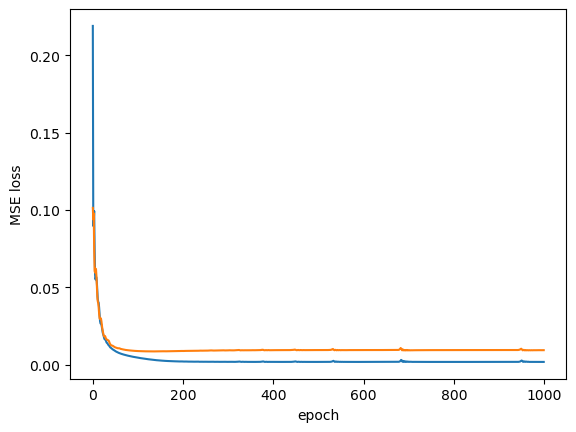

In [58]:
# Visualize MSE loss values over time
plt.plot(train_losses)
plt.plot(val_losses)
plt.xlabel('epoch')
plt.ylabel('MSE loss')

**g. Evaluation**

In [59]:
# Set the model to evaluation mode
model.eval()

# Forward the test set
y_pred_scaled = model(x_test)

# Scale output back to original range
y_pred = output_scaler.inverse_transform(y_pred_scaled.detach().cpu().numpy().reshape(-1, 1)).reshape(-1)

# Transform the test set back to original scale
y_test = output_scaler.inverse_transform(y_test_scaled.reshape(-1, 1)).reshape(-1)

In [60]:
# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = math.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R^2 Score: {r2:.4f}")

Mean Absolute Error (MAE): 6.6646
Mean Squared Error (MSE): 106.8474
Root Mean Squared Error (RMSE): 10.3367
R^2 Score: 0.8566


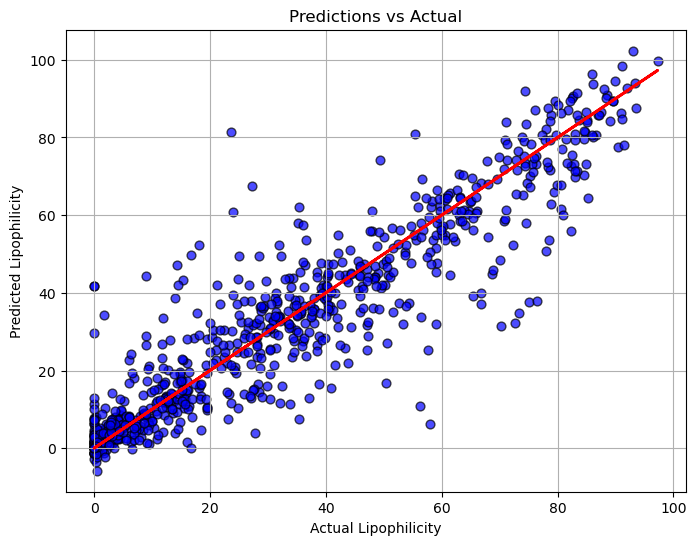

In [61]:
# Plotting the results
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.7, s=40)
plt.plot(y_test, y_test, color='red', linewidth=2)  # Ideal line for perfect predictions
plt.xlabel('Actual Lipophilicity')
plt.ylabel('Predicted Lipophilicity')
plt.title('Predictions vs Actual')
plt.grid(True)
plt.show()

**h. Save and load model**

In [62]:
# Save model
model_name = 'mlp_model'
file_name = f'{model_name}_{num_epochs}.ckpt'
torch.save(model.state_dict(), file_name)

In [63]:
# Load model
file_name = f'mlp_model_1000.ckpt'
loaded_model = RegressionModel(n_inputs, n_layers, n_hiddens, n_outputs)
loaded_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>